# 11. Evaluate Shared-E2E Encoder-Representation Projected

동일한 VOC2007 validation split에서 `baseline`, `shared_e2e`, `shared_e2e_rep_projected`의 현재 seed 42/43/44 checkpoint를 직접 재추론합니다. 새 모델은 encoder parameter 전체가 아니라 공유 encoder 출력 representation에서 conflict surgery를 수행합니다. 평가는 서로 섞이지 않는 세 묶음으로 나눕니다.

- Detection: semantic mAP/AP50/AP75/AR100
- Localization: 모든 label을 object로 통일한 AP, matched IoU, center/size error
- Classification: training과 같은 Hungarian match의 query class accuracy와 GT score, focal classification loss, IoU 0.5에서의 classification FP

Classification FP는 score 0.1 이상 detection 중 가장 가까운 GT와 IoU가 0.5 이상이지만 class가 다른 경우로 명시적으로 정의합니다. VOC smoke checkpoint의 score 분포에서 0.5는 detection이 거의 남지 않으므로 0.1을 고정합니다.

In [15]:
from pathlib import Path
import gc, importlib, sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (Path('D:/gt-super') / 'data').exists():
    ROOT = Path('D:/gt-super')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import gt_aux.config as config_module
import gt_aux.data as data_module
import gt_aux.model as model_module
import gt_aux.eval as eval_module
config_module = importlib.reload(config_module)
data_module = importlib.reload(data_module)
model_module = importlib.reload(model_module)
eval_module = importlib.reload(eval_module)

ExperimentConfig = config_module.ExperimentConfig
prepare_data, make_loaders = data_module.prepare_data, data_module.make_loaders
load_checkpoint = eval_module.load_checkpoint
evaluate_main = eval_module.evaluate_main
collect_localization_predictions = eval_module.collect_localization_predictions
localization_metrics = eval_module.localization_metrics
localization_geometry_metrics = eval_module.localization_geometry_metrics
classification_diagnostics = eval_module.classification_diagnostics

## 1. 평가 설정과 checkpoint 무결성

학습 노트북과 같은 split, image size, batch size를 사용합니다. 하나라도 없거나 7 epoch 미만이면 중단해 불완전한 모델이 평균에 섞이지 않게 합니다.

In [16]:
RUN_MODE = 'smoke'
SEEDS = [42, 43, 44]
DATA_SEED = 42
EXPERIMENTS = ['baseline', 'shared_e2e', 'shared_e2e_rep_projected']
TRAIN_IMAGES, VAL_IMAGES, EPOCHS = 400, 100, 7
BATCH_SIZE, IMAGE_MIN_SIZE, IMAGE_MAX_SIZE = 2, 384, 640
CLASSIFICATION_SCORE_THRESHOLD = 0.1
CLASSIFICATION_IOU_THRESHOLD = 0.5
RUN_INFERENCE = False  # Existing raw evaluation CSV is reused for plotting.
STRICT_CHECKPOINTS = True

CONFIG = ExperimentConfig.for_run(
    ROOT, run_mode=RUN_MODE, seed=SEEDS[0], data_seed=DATA_SEED,
    experiments=EXPERIMENTS, train_images=TRAIN_IMAGES, val_images=VAL_IMAGES,
    epochs=EPOCHS, batch_size=BATCH_SIZE, image_min_size=IMAGE_MIN_SIZE,
    image_max_size=IMAGE_MAX_SIZE, feature_level=0, base_aux_weight=0.5,
)
CONFIG.as_dict()

{'root': 'D:\\gt-super',
 'run_mode': 'smoke',
 'checkpoint': 'SenseTime/deformable-detr',
 'train_images': 400,
 'val_images': 100,
 'epochs': 7,
 'batch_size': 2,
 'num_workers': 0,
 'image_size': {'shortest_edge': 384, 'longest_edge': 640},
 'lr': 0.0002,
 'backbone_lr': 2e-05,
 'weight_decay': 0.0001,
 'grad_clip': 0.1,
 'base_aux_weight': 0.5,
 'feature_level': 0,
 'horizontal_flip_p': 0.5,
 'use_amp': True,
 'deterministic': True,
 'save_epoch_checkpoints': False,
 'device': 'cuda',
 'experiments': ['baseline', 'shared_e2e', 'shared_e2e_rep_projected'],
 'seed': 42,
 'data_seed': 42}

In [17]:
BUNDLE = prepare_data(CONFIG)
checkpoint_rows = []
for experiment in EXPERIMENTS:
    for seed in SEEDS:
        path = CONFIG.checkpoint_path(experiment, seed)
        epoch = None
        history_path = CONFIG.history_path(experiment, seed)
        if history_path.exists():
            history = pd.read_csv(history_path)
            epoch = int(history['epoch'].max()) if not history.empty else None
        checkpoint_rows.append({
            'experiment': experiment, 'seed': seed, 'exists': path.exists(),
            'epoch': epoch, 'path': str(path),
        })
checkpoint_df = pd.DataFrame(checkpoint_rows)
display(checkpoint_df)
invalid = checkpoint_df[(~checkpoint_df['exists']) | (checkpoint_df['epoch'] != EPOCHS)]
if STRICT_CHECKPOINTS and not invalid.empty:
    raise FileNotFoundError(
        'Missing or incomplete checkpoints. Run 01_train_experiments.ipynb and '
        '01-3_train_shared_e2e_projected.ipynb first:\n' +
        '\n'.join(invalid['path'])
    )

VOC XML: 100%|██████████| 3750/3750 [00:01<00:00, 3284.96it/s]

Full split: train=3000 (9180 objects), val=750 (2530 objects)
Current run: train=400, val=100


,experiment,seed,exists,epoch,path
0,baseline,42,True,7,D:\gt-super\cache\checkpoints\baseline\seed_42...
1,baseline,43,True,7,D:\gt-super\cache\checkpoints\baseline\seed_43...
2,baseline,44,True,7,D:\gt-super\cache\checkpoints\baseline\seed_44...
3,shared_e2e,42,True,7,D:\gt-super\cache\checkpoints\shared_e2e\seed_...
4,shared_e2e,43,True,7,D:\gt-super\cache\checkpoints\shared_e2e\seed_...
5,shared_e2e,44,True,7,D:\gt-super\cache\checkpoints\shared_e2e\seed_...
6,shared_e2e_rep_projected,42,True,7,D:\gt-super\cache\checkpoints\shared_e2e_rep_p...
7,shared_e2e_rep_projected,43,True,7,D:\gt-super\cache\checkpoints\shared_e2e_rep_p...
8,shared_e2e_rep_projected,44,True,7,D:\gt-super\cache\checkpoints\shared_e2e_rep_p...


## 2. 현재 checkpoint 직접 재평가

각 모델을 한 번에 하나만 GPU에 올리고 평가 후 즉시 해제합니다. 과거 notebook output이나 종합 cache의 metric은 재사용하지 않습니다.

In [18]:
RAW_PATH = CONFIG.output_dir / 'shared_e2e_rep_projected_evaluation_raw.csv'
rows = []
if RUN_INFERENCE:
    for experiment in EXPERIMENTS:
        for seed in SEEDS:
            print(f'[{experiment} / seed={seed}]')
            _, val_loader = make_loaders(CONFIG, BUNDLE, seed)
            model, checkpoint, fingerprint = load_checkpoint(CONFIG, BUNDLE, experiment, seed)
            predictions = targets = None
            try:
                detection = evaluate_main(model, val_loader, BUNDLE.processor, CONFIG)
                predictions, targets = collect_localization_predictions(
                    model, val_loader, BUNDLE.processor, CONFIG
                )
                localization = {
                    **localization_metrics(predictions, targets),
                    **localization_geometry_metrics(predictions, targets, max_detections=100),
                }
                classification = classification_diagnostics(
                    model, val_loader, BUNDLE.processor, CONFIG,
                    score_threshold=CLASSIFICATION_SCORE_THRESHOLD,
                    iou_threshold=CLASSIFICATION_IOU_THRESHOLD,
                )
                row = {
                    'experiment': experiment, 'seed': seed,
                    'checkpoint_epoch': checkpoint.get('epoch'),
                    'fingerprint': fingerprint, **detection, **localization, **classification,
                }
                rows.append(row)
                print({key: round(value, 4) for key, value in row.items() if key in {
                    'map', 'map75', 'loc_ap75', 'matched_iou',
                    'matched_query_class_accuracy', 'mean_cls_loss',
                    'classification_fp_per_image',
                }})
            finally:
                model.close()
                model.cpu()
                del model, checkpoint, predictions, targets
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
    results_df = pd.DataFrame(rows)
    results_df.to_csv(RAW_PATH, index=False)
else:
    results_df = pd.read_csv(RAW_PATH)
print('Saved/loaded:', RAW_PATH)
display(results_df)

Saved/loaded: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_rep_projected_evaluation_raw.csv


,experiment,seed,checkpoint_epoch,fingerprint,map,map50,map75,mar100,val_seconds,loc_map,...,matched_query_mean_gt_score,matched_queries,classification_fp_count,classification_fp_per_image,classification_fp_rate,background_fp_count,background_fp_per_image,detections_at_threshold,classification_score_threshold,classification_iou_threshold
0,baseline,42,7,c16286f63961237b,0.059872,0.110153,0.059278,0.391496,5.596728,0.125056,...,0.109335,311,899,8.99,0.281995,976,9.76,3188,0.1,0.5
1,baseline,43,7,d1b7a9f86e187c5e,0.103289,0.162047,0.109564,0.437702,5.255085,0.179728,...,0.118440,311,1869,18.69,0.485455,871,8.71,3850,0.1,0.5
2,baseline,44,7,9fffb715f8680daa,0.043373,0.081491,0.046653,0.334737,5.253709,0.108407,...,0.103377,311,889,8.89,0.296333,989,9.89,3000,0.1,0.5
3,shared_e2e,42,7,c16286f63961237b,0.069646,0.114608,0.075431,0.394205,5.166220,0.144485,...,0.117985,311,1476,14.76,0.379142,1115,11.15,3893,0.1,0.5
4,shared_e2e,43,7,d1b7a9f86e187c5e,0.107322,0.170547,0.105593,0.404736,5.250383,0.155968,...,0.116757,311,1736,17.36,0.435415,932,9.32,3987,0.1,0.5
5,shared_e2e,44,7,9fffb715f8680daa,0.063477,0.104559,0.063565,0.411831,5.206245,0.124314,...,0.109700,311,1359,13.59,0.383790,961,9.61,3541,0.1,0.5
6,shared_e2e_rep_projected,42,7,c16286f63961237b,0.094562,0.160022,0.101423,0.427689,5.290398,0.166000,...,0.121685,311,1406,14.06,0.375234,1047,10.47,3747,0.1,0.5
7,shared_e2e_rep_projected,43,7,d1b7a9f86e187c5e,0.126917,0.189808,0.141917,0.481243,5.247478,0.155867,...,0.123968,311,1853,18.53,0.426369,1145,11.45,4346,0.1,0.5
8,shared_e2e_rep_projected,44,7,9fffb715f8680daa,0.061714,0.106904,0.065998,0.395605,5.218663,0.106465,...,0.109125,311,1028,10.28,0.318957,923,9.23,3223,0.1,0.5


## 3. 세 축 평균·표준편차와 paired seed delta

평균만 보지 않고 같은 initialization seed끼리 `projected - reference`를 계산합니다. error/loss/FP 계열은 음수 delta가 개선입니다.

In [19]:
DETECTION_METRICS = ['map', 'map50', 'map75', 'mar100']
LOCALIZATION_METRICS = [
    'loc_map', 'loc_ap50', 'loc_ap75', 'loc_ar100',
    'loc_ap_small', 'loc_ap_medium', 'loc_ap_large',
    'matched_iou', 'center_error_l2', 'size_error_l1',
    'geometry_recall50', 'geometry_recall75',
]
CLASSIFICATION_METRICS = [
    'matched_query_class_accuracy', 'matched_query_mean_gt_score',
    'mean_cls_loss', 'classification_fp_per_image',
    'classification_fp_rate', 'background_fp_per_image',
]
ALL_METRICS = DETECTION_METRICS + LOCALIZATION_METRICS + CLASSIFICATION_METRICS
summary = results_df.groupby('experiment')[ALL_METRICS].agg(['mean', 'std', 'count'])
summary_path = CONFIG.output_dir / 'shared_e2e_rep_projected_evaluation_summary.csv'
summary.to_csv(summary_path)
display(summary)
print('Saved:', summary_path)

delta_frames = []
projected = results_df.query("experiment == 'shared_e2e_rep_projected'").set_index('seed')[ALL_METRICS]
for reference in ['baseline', 'shared_e2e']:
    reference_df = results_df.query('experiment == @reference').set_index('seed')[ALL_METRICS]
    common = projected.index.intersection(reference_df.index)
    delta = projected.loc[common] - reference_df.loc[common]
    delta['reference'] = reference
    delta['seed'] = common
    delta_frames.append(delta.reset_index(drop=True))
paired_delta_df = pd.concat(delta_frames, ignore_index=True)
delta_path = CONFIG.output_dir / 'shared_e2e_rep_projected_paired_deltas.csv'
paired_delta_df.to_csv(delta_path, index=False)
display(paired_delta_df.groupby('reference')[ALL_METRICS].agg(['mean', 'std']))
print('Saved:', delta_path)

map                     map50                  \
                              mean       std count      mean       std count   
experiment                                                                     
baseline                  0.068845  0.030949     3  0.117897  0.040832     3   
shared_e2e                0.080148  0.023734     3  0.129905  0.035554     3   
shared_e2e_rep_projected  0.094398  0.032602     3  0.152245  0.041995     3   

                             map75                    mar100  ...  \
                              mean       std count      mean  ...   
experiment                                                    ...   
baseline                  0.071832  0.033281     3  0.387978  ...   
shared_e2e                0.081530  0.021667     3  0.403591  ...   
shared_e2e_rep_projected  0.103113  0.037988     3  0.434845  ...   

                         mean_cls_loss classification_fp_per_image            \
                                 count                        mean       std   
experiment                                                                     
baseline                             3                   12.190000  5.629387   
shared_e2e                           3                   15.236667  1.929672   
shared_e2e_rep_projected             3                   14.290000  4.129806   

                               classification_fp_rate                  \
                         count                   mean       std count   
experiment                                                              
baseline                     3               0.354594  0.113555     3   
shared_e2e                   3               0.399449  0.031234     3   
shared_e2e_rep_projected     3               0.373520  0.053726     3   

                         background_fp_per_image                  
                                            mean       std count  
experiment                                                        
baseline                                9.453333  0.647019     3  
shared_e2e                             10.026667  0.983582     3  
shared_e2e_rep_projected               10.383333  1.112535     3  

[3 rows x 66 columns]

Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_rep_projected_evaluation_summary.csv


map               map50               map75            \
                mean       std      mean       std      mean       std   
reference                                                                
baseline    0.025553  0.008343  0.034348  0.013493  0.031281  0.011438   
shared_e2e  0.014250  0.014120  0.022340  0.021699  0.021583  0.017371   

              mar100             loc_map            ...  \
                mean       std      mean       std  ...   
reference                                           ...   
baseline    0.046867  0.012669  0.005047  0.032963  ...   
shared_e2e  0.031255  0.046406  0.001189  0.019714  ...   

           matched_query_mean_gt_score           mean_cls_loss            \
                                  mean       std          mean       std   
reference                                                                  
baseline                      0.007876  0.003877     -0.026197  0.027383   
shared_e2e                    0.003445  0.003899     -0.008431  0.014609   

           classification_fp_per_image           classification_fp_rate  \
                                  mean       std                   mean   
reference                                                                 
baseline                      2.100000  2.686317               0.018926   
shared_e2e                   -0.946667  2.250163              -0.025929   

                     background_fp_per_image            
                 std                    mean       std  
reference                                               
baseline    0.076229                0.930000  1.710643  
shared_e2e  0.033789                0.356667  1.543060  

[2 rows x 44 columns]

Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_rep_projected_paired_deltas.csv


## 4. Gradient mechanism과 성능 변화 연결

Projected 모델의 step log에서 epoch conflict rate와 제거 비율을 다시 계산합니다. 이 값은 projection이 실제로 언제/얼마나 작동했는지 보여 주며 AP 자체와 다른 mechanism evidence입니다.

In [20]:
gradient_frames = []
for seed in SEEDS:
    path = CONFIG.gradients_path('shared_e2e_rep_projected', seed)
    if not path.exists():
        raise FileNotFoundError(path)
    gradient_frames.append(pd.read_csv(path))
gradient_df = pd.concat(gradient_frames, ignore_index=True)
gradient_df['projection_applied_on_update'] = gradient_df['projection_applied'].where(
    ~gradient_df['optimizer_step_skipped'].astype(bool)
)
mechanism_df = gradient_df.groupby(['seed', 'epoch']).agg(
    conflict_rate=('projection_applied', 'mean'),
    update_conflict_rate=('projection_applied_on_update', 'mean'),
    optimizer_skip_rate=('optimizer_step_skipped', 'mean'),
    raw_cosine_mean=('enc_cls_aux_cosine_raw', 'mean'),
    raw_cosine_median=('enc_cls_aux_cosine_raw', 'median'),
    removed_ratio_mean=('projection_removed_ratio', 'mean'),
    cls_norm_mean=('enc_cls_grad_norm', 'mean'),
    aux_norm_mean=('enc_aux_grad_norm', 'mean'),
    projected_aux_norm_mean=('enc_aux_grad_norm_projected', 'mean'),
    projection_vector_mb=('projection_vector_mb', 'mean'),
).reset_index()
mechanism_path = CONFIG.output_dir / 'shared_e2e_rep_projected_evaluation_mechanism.csv'
mechanism_df.to_csv(mechanism_path, index=False)
display(mechanism_df)
print('Saved:', mechanism_path)

,seed,epoch,conflict_rate,update_conflict_rate,optimizer_skip_rate,raw_cosine_mean,raw_cosine_median,removed_ratio_mean,cls_norm_mean,aux_norm_mean,projected_aux_norm_mean,projection_vector_mb
0,42,1,0.545,0.544503,0.045,0.000184,-1.737825e-04,0.000004,0.229873,1.237849,1.237843,9.555127
1,42,2,0.465,0.465,0.000,0.000472,1.450042e-04,0.000010,0.017033,1.046699,1.046688,9.524912
2,42,3,0.410,0.41,0.000,0.001181,6.023087e-04,0.000009,0.021916,0.958674,0.958665,9.597393
3,42,4,0.365,0.365,0.000,0.001179,1.158485e-03,0.000010,0.022060,0.867185,0.867175,9.620654
4,42,5,0.450,0.45,0.000,0.001407,4.389717e-04,0.000006,0.023834,0.843601,0.843595,9.584980
5,42,6,0.445,0.445,0.000,0.001205,4.238903e-04,0.000016,0.025404,0.819940,0.819924,9.484033
6,42,7,0.465,0.465,0.000,0.000453,2.400598e-04,0.000012,0.025816,0.800512,0.800502,9.509326
7,43,1,0.520,0.52356,0.045,0.000347,-3.430823e-05,0.000003,0.152148,1.542237,1.542231,9.506611
8,43,2,0.450,0.45,0.000,0.000561,1.341913e-04,0.000010,0.016972,1.158139,1.158126,9.461973
9,43,3,0.470,0.47,0.000,0.001151,1.473849e-04,0.000006,0.020945,0.970236,0.970230,9.531582


Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_rep_projected_evaluation_mechanism.csv


## 5. Detection / Localization / Classification 시각화

Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_rep_projected_evaluation.png


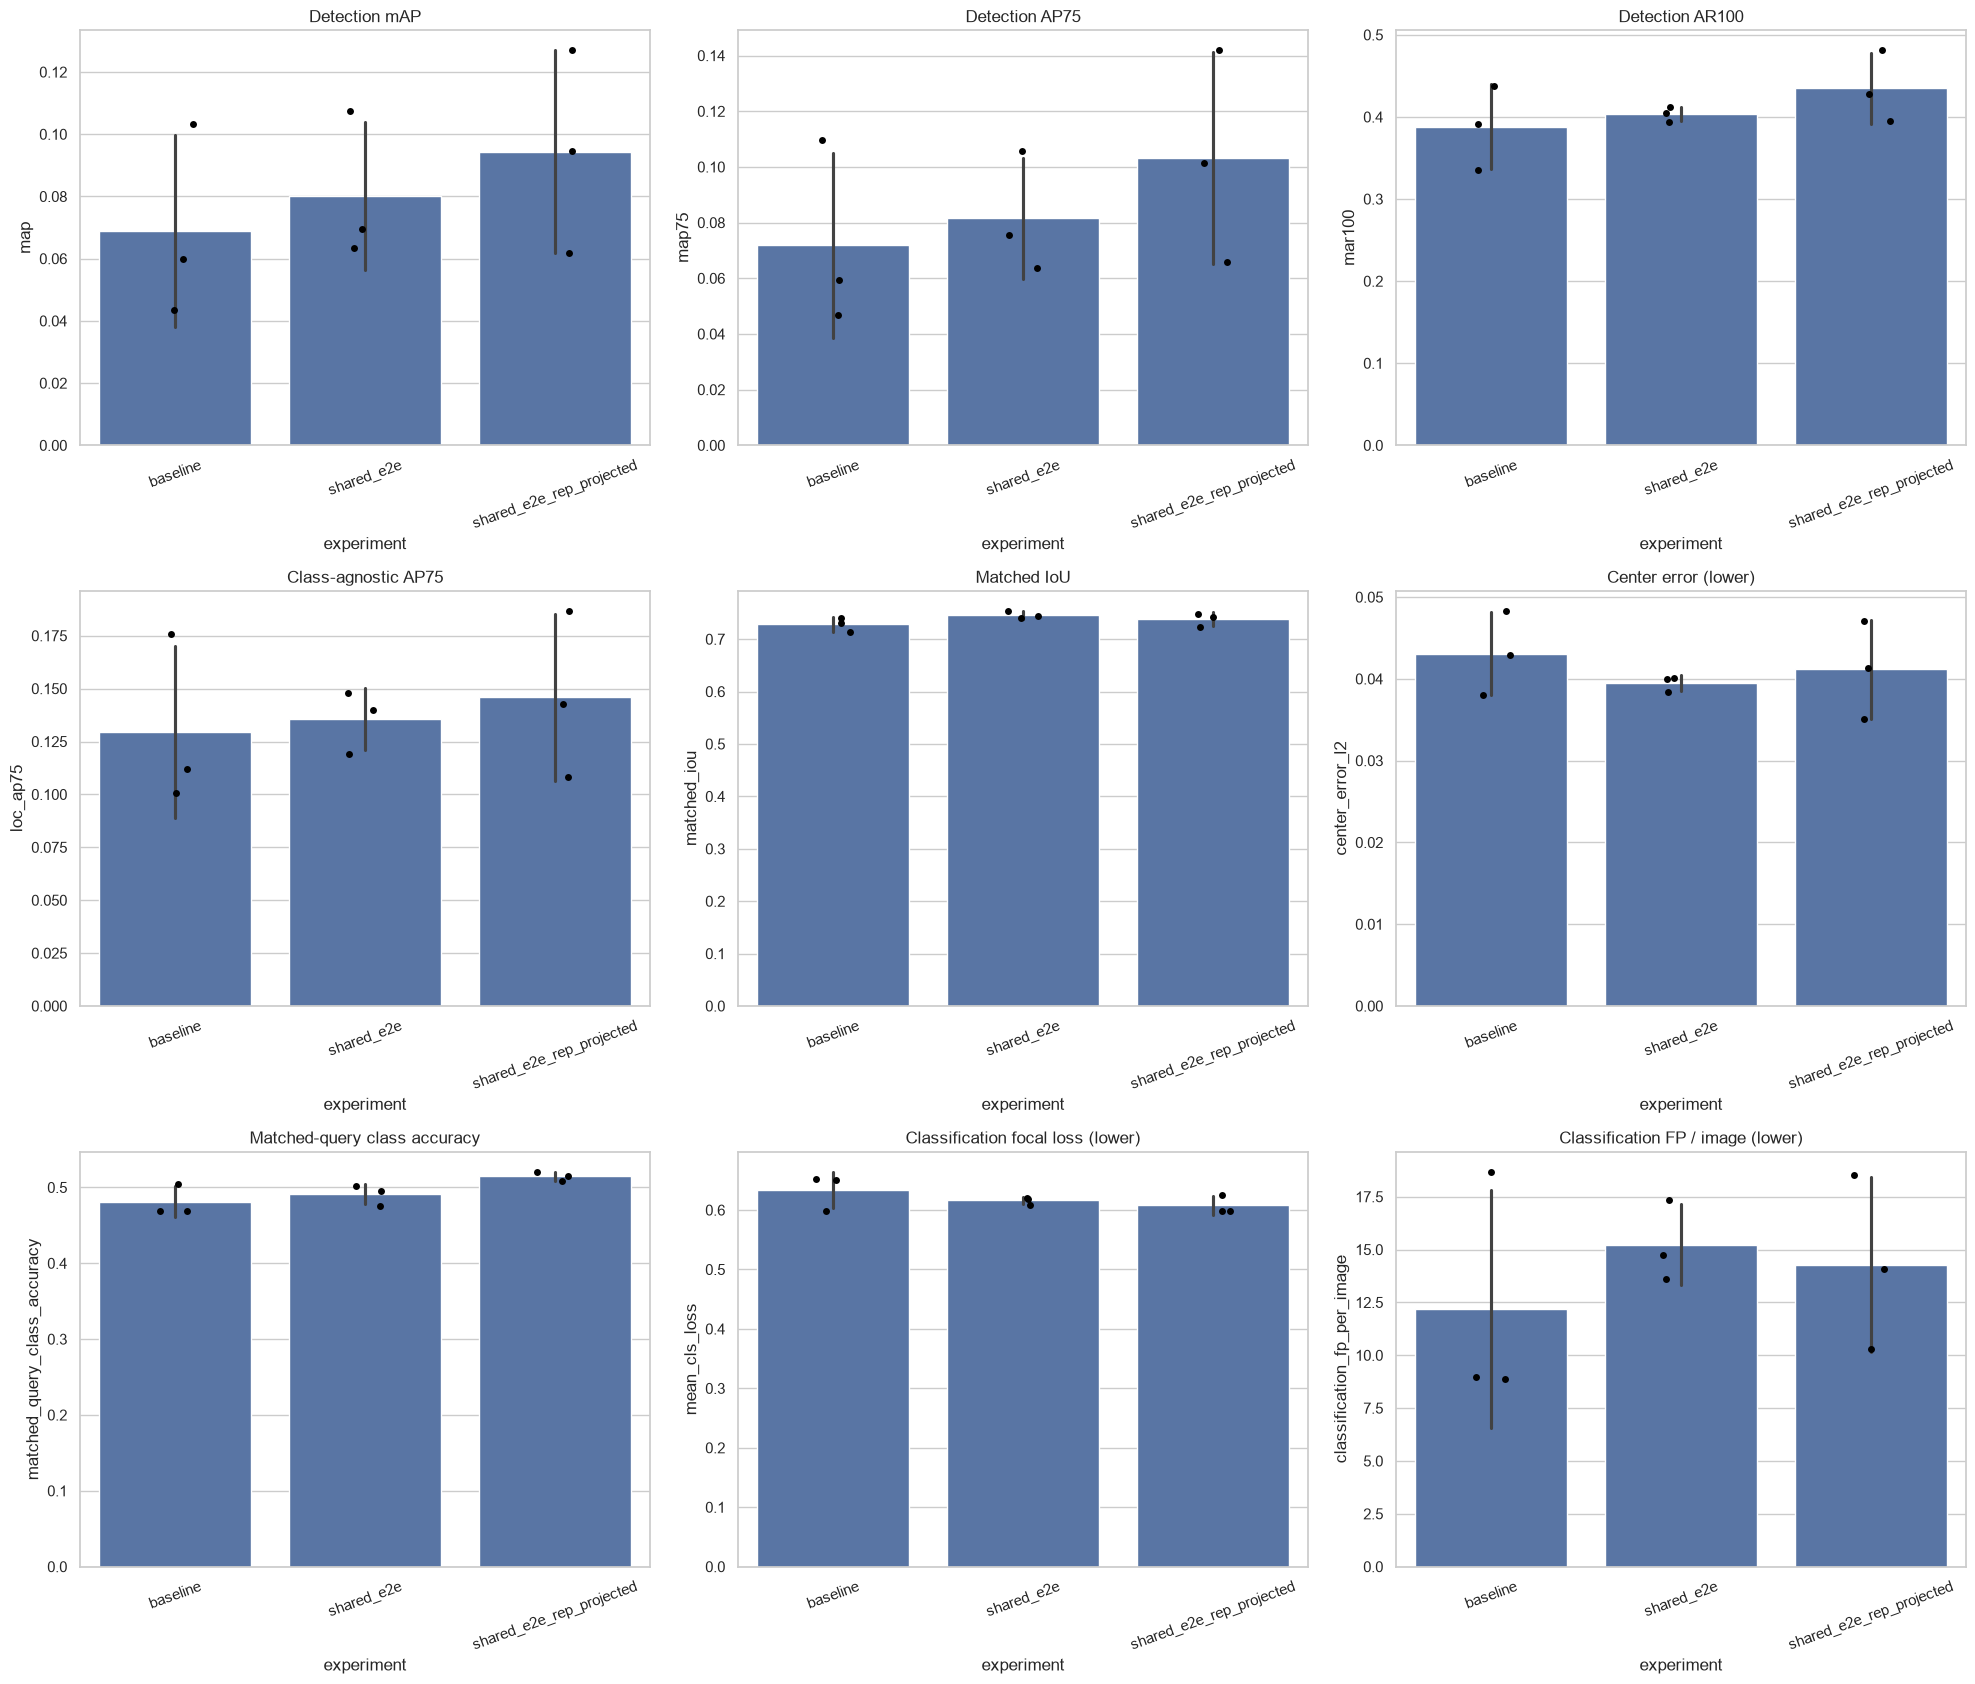

In [21]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(3, 3, figsize=(20, 17))
plot_specs = [
    ('map', 'Detection mAP', False),
    ('map75', 'Detection AP75', False),
    ('mar100', 'Detection AR100', False),
    ('loc_ap75', 'Class-agnostic AP75', False),
    ('matched_iou', 'Matched IoU', False),
    ('center_error_l2', 'Center error (lower)', True),
    ('matched_query_class_accuracy', 'Matched-query class accuracy', False),
    ('mean_cls_loss', 'Classification focal loss (lower)', True),
    ('classification_fp_per_image', 'Classification FP / image (lower)', True),
]
for axis, (metric, title, lower_is_better) in zip(axes.flat, plot_specs):
    sns.barplot(data=results_df, x='experiment', y=metric, errorbar='sd', ax=axis)
    sns.stripplot(data=results_df, x='experiment', y=metric, color='black', size=5, ax=axis)
    axis.set_title(title)
    axis.tick_params(axis='x', rotation=20)
plt.tight_layout()
figure_path = CONFIG.output_dir / 'shared_e2e_rep_projected_evaluation.png'
fig.savefig(figure_path, dpi=180, bbox_inches='tight')
print('Saved:', figure_path)
plt.show()

Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_rep_projected_mechanism.png


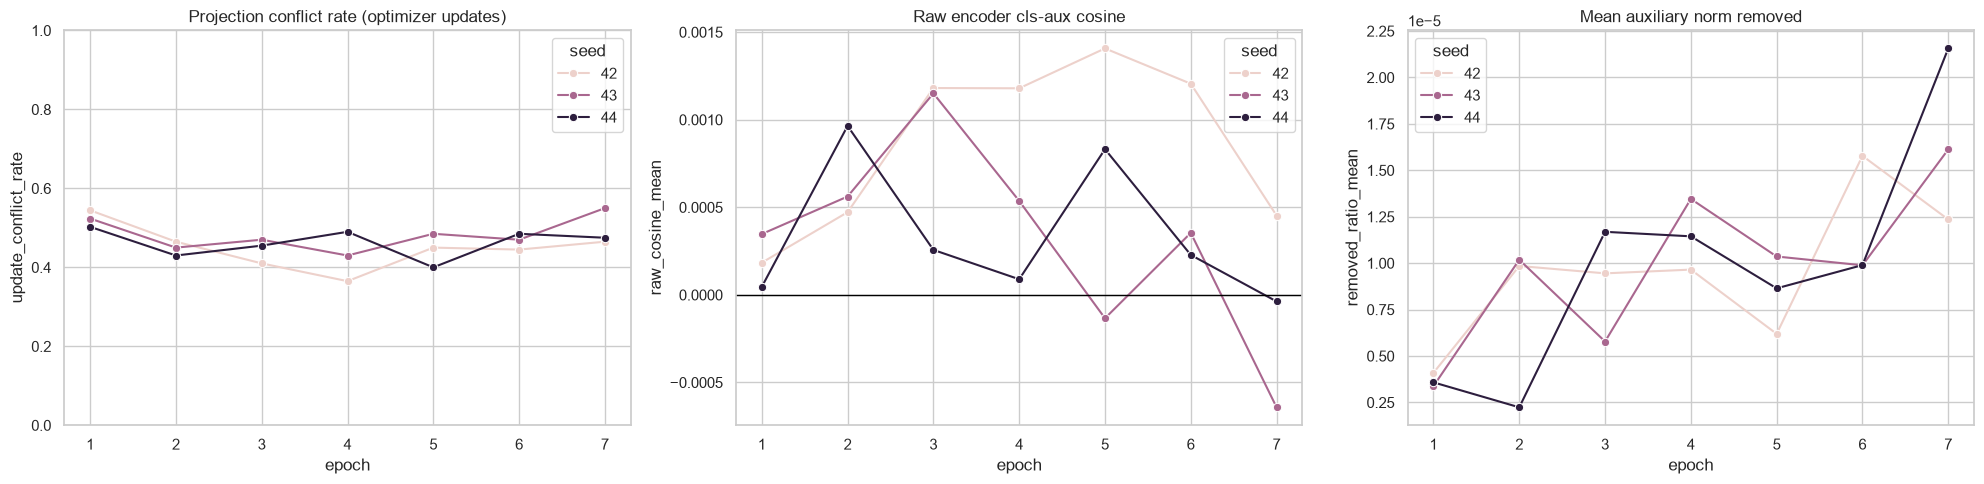

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.lineplot(data=mechanism_df, x='epoch', y='update_conflict_rate', hue='seed', marker='o', ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title('Projection conflict rate (optimizer updates)')
sns.lineplot(data=mechanism_df, x='epoch', y='raw_cosine_mean', hue='seed', marker='o', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Raw encoder cls-aux cosine')
sns.lineplot(data=mechanism_df, x='epoch', y='removed_ratio_mean', hue='seed', marker='o', ax=axes[2])
axes[2].set_title('Mean auxiliary norm removed')
plt.tight_layout()
mechanism_figure_path = CONFIG.output_dir / 'shared_e2e_rep_projected_mechanism.png'
fig.savefig(mechanism_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', mechanism_figure_path)
plt.show()

## 판정 기준

목표 패턴은 `Representation-Projected localization ≈ Shared-E2E > Baseline`이면서 `Representation-Projected classification ≈ Baseline > Shared-E2E`입니다. 다만 projection은 현재 mini-batch의 공유 encoder representation에서 auxiliary gradient가 classification gradient에 직접 반대되는 성분만 제거합니다. 최종 classification 성능을 수학적으로 보장하지 않으므로 세 seed의 paired delta, 표준편차, conflict rate와 01-3의 시간·peak memory probe를 함께 해석합니다.

## 10. 03과 동일한 통합 그래프용 상세 평가

비교 대상은 `baseline`, `shared_e2e`, `shared_e2e_rep_projected` 세 모델로 고정합니다. 기존 03/04 cache에서 baseline과 Shared-E2E를 재사용하고, V2 상세 결과가 없을 때만 checkpoint를 평가해 cache를 완성합니다.

In [23]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm

ID2LABEL = config_module.ID2LABEL
IOU_THRESHOLDS = [round(0.50 + 0.05 * i, 2) for i in range(10)]
RUN_DETAILED_EVALUATION = True
DETAIL_PATH = CONFIG.output_dir / 'shared_e2e_rep_projection_comprehensive_metrics.csv'
SCALE_PATH = CONFIG.output_dir / 'shared_e2e_rep_projection_object_scale_metrics.csv'
COMPREHENSIVE_SOURCE = CONFIG.output_dir / 'comprehensive_metrics.csv'
OBJECT_SCALE_SOURCE = CONFIG.output_dir / 'object_scale_diagnostics_seeds42-43-44.csv'

def valid_scalar(value):
    value = float(value)
    return np.nan if value < 0 else value

def valid_mean(values):
    values = values[values >= 0]
    return float(values.mean()) if values.numel() else np.nan

@torch.inference_mode()
def collect_detailed_predictions(experiment, seed):
    _, val_loader = make_loaders(CONFIG, BUNDLE, seed)
    model, checkpoint, fingerprint = load_checkpoint(CONFIG, BUNDLE, experiment, seed)
    model.eval()
    predictions, targets = [], []
    try:
        for batch in tqdm(val_loader, desc=f'{experiment}/seed{seed}', leave=False):
            result = model(
                pixel_values=batch['pixel_values'].to(CONFIG.device, non_blocking=True),
                pixel_mask=batch['pixel_mask'].to(CONFIG.device, non_blocking=True),
                labels=None,
            )
            sizes = torch.stack([target['orig_size'] for target in batch['eval_targets']]).to(CONFIG.device)
            batch_predictions = BUNDLE.processor.post_process_object_detection(
                result['outputs'], threshold=0.0, target_sizes=sizes,
            )
            predictions.extend([{key: value.detach().cpu() for key, value in item.items()} for item in batch_predictions])
            targets.extend([
                {'boxes': target['boxes'].cpu(), 'labels': target['labels'].cpu()}
                for target in batch['eval_targets']
            ])
    finally:
        model.close()
        model.cpu()
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return predictions, targets, checkpoint.get('epoch'), fingerprint

def compute_detailed_rows(experiment, seed, predictions, targets, checkpoint_epoch, fingerprint):
    metric = MeanAveragePrecision(
        box_format='xyxy', iou_type='bbox', class_metrics=True,
        extended_summary=True, iou_thresholds=IOU_THRESHOLDS,
    )
    metric.update(predictions, targets)
    result = metric.compute()
    detail_rows, scale_rows = [], []
    for key, source in [('all', 'map'), ('small', 'map_small'), ('medium', 'map_medium'), ('large', 'map_large')]:
        detail_rows.append({'experiment': experiment, 'seed': seed, 'metric_type': 'area', 'key': key, 'value': valid_scalar(result[source]), 'scale': pd.NA})
    class_ids = result['classes'].reshape(-1).tolist()
    for class_id, value in zip(class_ids, result['map_per_class'].reshape(-1).tolist()):
        detail_rows.append({'experiment': experiment, 'seed': seed, 'metric_type': 'class', 'key': ID2LABEL[int(class_id)], 'value': valid_scalar(value), 'scale': pd.NA})
    precision = result['precision']
    for class_index, class_id in enumerate(class_ids):
        for scale, area_index in [('small', 1), ('medium', 2), ('large', 3)]:
            detail_rows.append({
                'experiment': experiment, 'seed': seed, 'metric_type': 'class_scale',
                'key': ID2LABEL[int(class_id)], 'scale': scale,
                'value': valid_mean(precision[:, :, class_index, area_index, -1]),
            })
    for threshold_index, threshold in enumerate(IOU_THRESHOLDS):
        detail_rows.append({
            'experiment': experiment, 'seed': seed, 'metric_type': 'iou',
            'key': f'{threshold:.2f}', 'value': valid_mean(precision[threshold_index, :, :, 0, -1]),
            'scale': pd.NA,
        })
    for scale, suffix, area_index in [('small', 'small', 1), ('medium', 'medium', 2), ('large', 'large', 3)]:
        scale_rows.append({
            'experiment': experiment, 'seed': seed, 'scale': scale,
            'checkpoint_epoch': checkpoint_epoch, 'fingerprint': fingerprint,
            'AP': valid_scalar(result[f'map_{suffix}']),
            'AP50': valid_mean(precision[IOU_THRESHOLDS.index(0.50), :, :, area_index, -1]),
            'AP75': valid_mean(precision[IOU_THRESHOLDS.index(0.75), :, :, area_index, -1]),
            'AR': valid_scalar(result[f'mar_{suffix}']),
        })
    return detail_rows, scale_rows

if DETAIL_PATH.exists():
    detail_df = pd.read_csv(DETAIL_PATH)
else:
    detail_df = pd.read_csv(COMPREHENSIVE_SOURCE).query("experiment in ['baseline', 'shared_e2e']").copy()
if 'scale' not in detail_df.columns:
    detail_df['scale'] = pd.NA
if SCALE_PATH.exists():
    scale_df = pd.read_csv(SCALE_PATH)
else:
    scale_df = pd.read_csv(OBJECT_SCALE_SOURCE).query("experiment in ['baseline', 'shared_e2e']").copy()

detail_counts = detail_df.groupby(['experiment', 'seed']).size()
scale_counts = scale_df.groupby(['experiment', 'seed']).size()
complete_pairs = {
    pair for pair in detail_counts.index
    if detail_counts.loc[pair] >= 94 and pair in scale_counts.index and scale_counts.loc[pair] >= 3
}
missing_pairs = [(experiment, seed) for experiment in EXPERIMENTS for seed in SEEDS if (experiment, seed) not in complete_pairs]
if missing_pairs and not RUN_DETAILED_EVALUATION:
    raise FileNotFoundError(f'Detailed cache is incomplete: {missing_pairs}')
for experiment, seed in missing_pairs:
    predictions, targets, checkpoint_epoch, fingerprint = collect_detailed_predictions(experiment, seed)
    new_detail, new_scale = compute_detailed_rows(experiment, seed, predictions, targets, checkpoint_epoch, fingerprint)
    detail_df = pd.concat([detail_df, pd.DataFrame(new_detail)], ignore_index=True)
    scale_df = pd.concat([scale_df, pd.DataFrame(new_scale)], ignore_index=True)
    del predictions, targets
    gc.collect()

detail_df = detail_df[detail_df['experiment'].isin(EXPERIMENTS) & detail_df['seed'].isin(SEEDS)].copy()
detail_df['_scale_key'] = detail_df['scale'].fillna('all')
detail_df = detail_df.drop_duplicates(['experiment', 'seed', 'metric_type', 'key', '_scale_key'], keep='last').drop(columns='_scale_key')
scale_df = scale_df[scale_df['experiment'].isin(EXPERIMENTS) & scale_df['seed'].isin(SEEDS)].drop_duplicates(['experiment', 'seed', 'scale'], keep='last')
detail_df.to_csv(DETAIL_PATH, index=False)
scale_df.to_csv(SCALE_PATH, index=False)
print('Saved:', DETAIL_PATH)
print('Saved:', SCALE_PATH)
display(scale_df.sort_values(['scale', 'experiment', 'seed']))

Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_rep_projection_comprehensive_metrics.csv
Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_rep_projection_object_scale_metrics.csv


,experiment,seed,scale,checkpoint_epoch,fingerprint,AP,AP50,AP75,AR
2,baseline,42,large,7,c16286f63961237b,0.098615,0.159605,0.106650,0.484060
8,baseline,43,large,7,d1b7a9f86e187c5e,0.176516,0.255326,0.207260,0.581242
14,baseline,44,large,7,9fffb715f8680daa,0.100141,0.164220,0.128579,0.407313
5,shared_e2e,42,large,7,c16286f63961237b,0.107784,0.170775,0.108268,0.497628
11,shared_e2e,43,large,7,d1b7a9f86e187c5e,0.140875,0.214953,0.138480,0.476494
17,shared_e2e,44,large,7,9fffb715f8680daa,0.093459,0.138970,0.100002,0.519638
20,shared_e2e_rep_projected,42,large,7,c16286f63961237b,0.136602,0.227793,0.130389,0.548678
23,shared_e2e_rep_projected,43,large,7,d1b7a9f86e187c5e,0.176755,0.254818,0.196995,0.586926
26,shared_e2e_rep_projected,44,large,7,9fffb715f8680daa,0.104270,0.164993,0.135269,0.479839
1,baseline,42,medium,7,c16286f63961237b,0.071162,0.147732,0.064594,0.222917


## 11. 03_comprehensive_analysis와 동일한 4×3 통합 그래프

Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_rep_projection_comprehensive_analysis.png


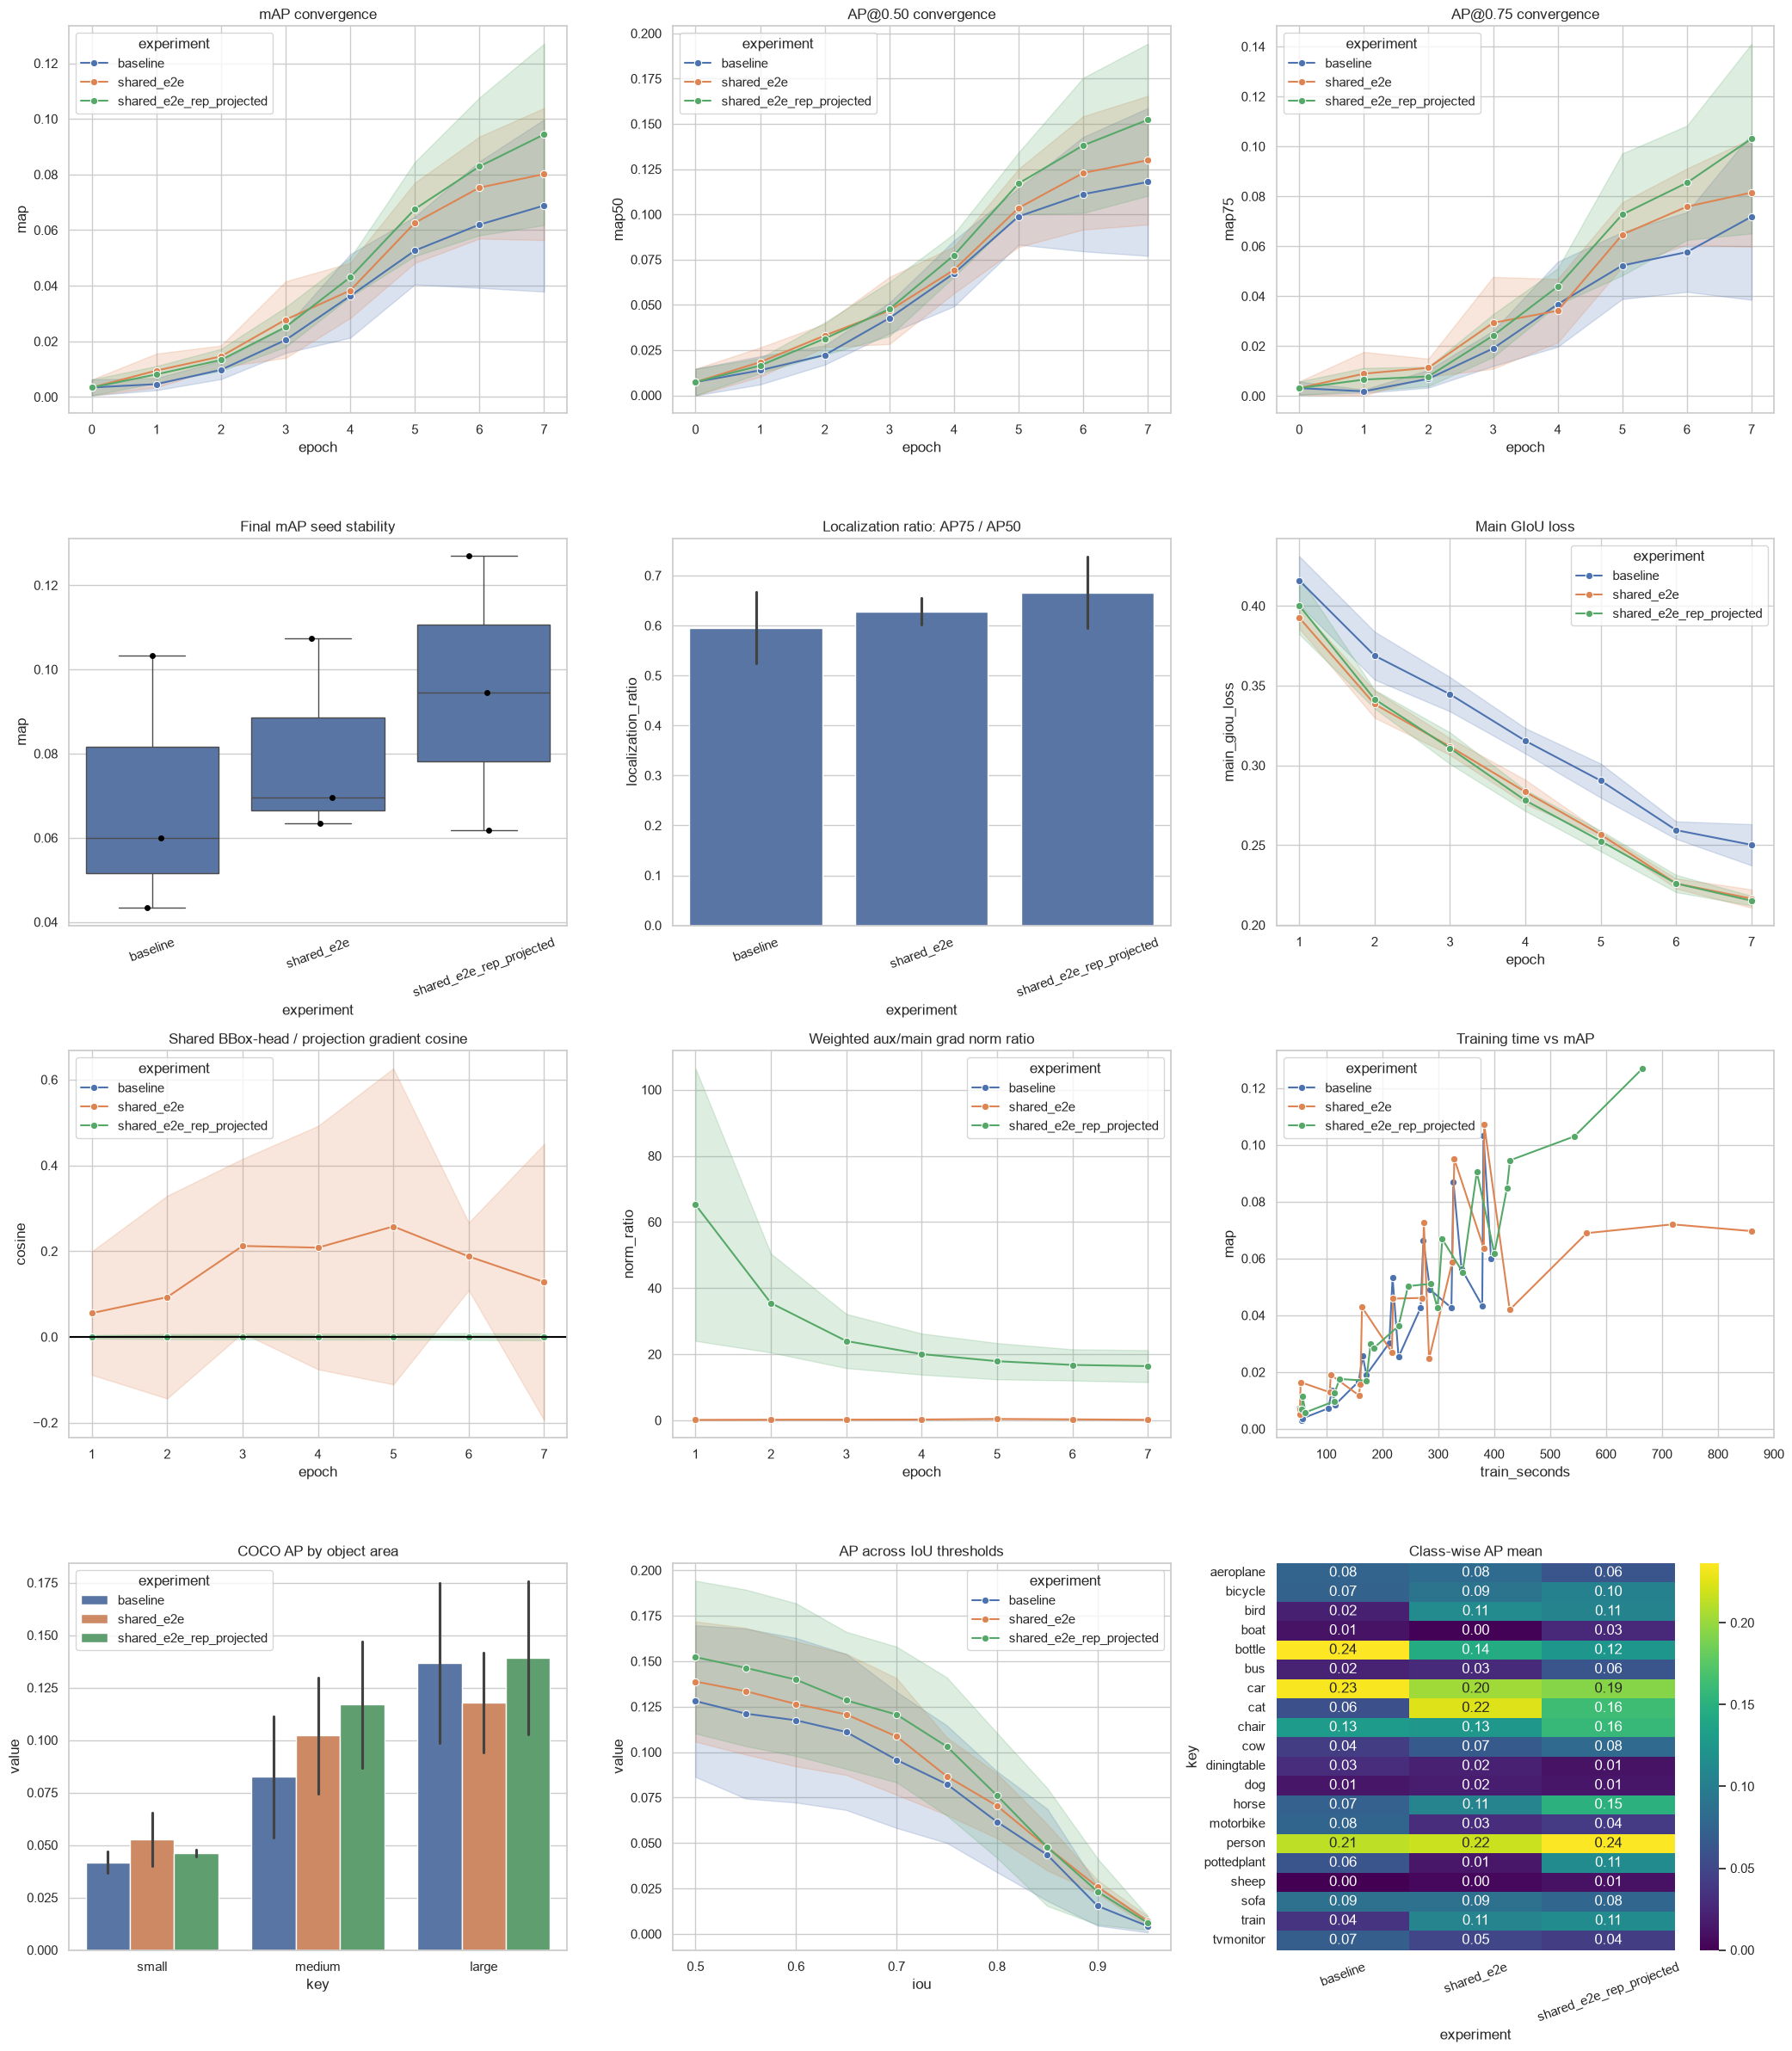

In [24]:
history_frames = []
for experiment in EXPERIMENTS:
    for seed in SEEDS:
        path = CONFIG.history_path(experiment, seed)
        if path.exists():
            history_frames.append(pd.read_csv(path))
history_df = pd.concat(history_frames, ignore_index=True)
all_gradient_frames = []
for experiment in EXPERIMENTS:
    for seed in SEEDS:
        path = CONFIG.gradients_path(experiment, seed)
        if path.exists() and path.stat().st_size > 0:
            try:
                all_gradient_frames.append(pd.read_csv(path))
            except pd.errors.EmptyDataError:
                pass
gradients_df = pd.concat(all_gradient_frames, ignore_index=True) if all_gradient_frames else pd.DataFrame()
final_df = history_df.sort_values('epoch').groupby(['experiment', 'seed'], as_index=False).tail(1).copy()
final_df['localization_ratio'] = final_df['map75'] / final_df['map50'].replace(0, np.nan)
FIGURE_PATH = CONFIG.output_dir / 'shared_e2e_rep_projection_comprehensive_analysis.png'

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(4, 3, figsize=(21, 24))
plot_specs = [('map','mAP convergence'), ('map50','AP@0.50 convergence'), ('map75','AP@0.75 convergence')]
for axis, (metric, title) in zip(axes[0], plot_specs):
    sns.lineplot(data=history_df, x='epoch', y=metric, hue='experiment', hue_order=EXPERIMENTS, estimator='mean', errorbar='sd' if len(SEEDS)>1 else None, marker='o', ax=axis)
    axis.set_title(title)
sns.boxplot(data=final_df, x='experiment', y='map', order=EXPERIMENTS, ax=axes[1,0]); sns.stripplot(data=final_df, x='experiment', y='map', order=EXPERIMENTS, color='black', ax=axes[1,0]); axes[1,0].set_title('Final mAP seed stability')
sns.barplot(data=final_df, x='experiment', y='localization_ratio', order=EXPERIMENTS, errorbar='sd' if len(SEEDS)>1 else None, ax=axes[1,1]); axes[1,1].set_title('Localization ratio: AP75 / AP50')
sns.lineplot(data=history_df.query('epoch > 0'), x='epoch', y='main_giou_loss', hue='experiment', hue_order=EXPERIMENTS, estimator='mean', errorbar='sd' if len(SEEDS)>1 else None, marker='o', ax=axes[1,2]); axes[1,2].set_title('Main GIoU loss')
if not gradients_df.empty:
    sns.lineplot(data=gradients_df, x='epoch', y='cosine', hue='experiment', hue_order=EXPERIMENTS, estimator='mean', errorbar='sd' if len(SEEDS)>1 else None, marker='o', ax=axes[2,0]); axes[2,0].axhline(0,color='black'); axes[2,0].set_title('Shared BBox-head / projection gradient cosine')
    sns.lineplot(data=gradients_df, x='epoch', y='norm_ratio', hue='experiment', hue_order=EXPERIMENTS, estimator='mean', errorbar='sd' if len(SEEDS)>1 else None, marker='o', ax=axes[2,1]); axes[2,1].set_title('Weighted aux/main grad norm ratio')
time_df = history_df.query('epoch > 0')
sns.lineplot(data=time_df, x='train_seconds', y='map', hue='experiment', hue_order=EXPERIMENTS, estimator='mean', marker='o', ax=axes[2,2]); axes[2,2].set_title('Training time vs mAP')
area_df = detail_df.query("metric_type == 'area' and key != 'all'")
sns.barplot(data=area_df, x='key', y='value', hue='experiment', hue_order=EXPERIMENTS, errorbar='sd' if len(SEEDS)>1 else None, ax=axes[3,0]); axes[3,0].set_title('COCO AP by object area')
iou_df = detail_df.query("metric_type == 'iou'").copy(); iou_df['iou'] = iou_df['key'].astype(float)
sns.lineplot(data=iou_df, x='iou', y='value', hue='experiment', hue_order=EXPERIMENTS, estimator='mean', errorbar='sd' if len(SEEDS)>1 else None, marker='o', ax=axes[3,1]); axes[3,1].set_title('AP across IoU thresholds')
class_df = detail_df.query("metric_type == 'class'").groupby(['key','experiment'])['value'].mean().unstack().reindex(columns=EXPERIMENTS)
sns.heatmap(class_df, annot=True, fmt='.2f', cmap='viridis', ax=axes[3,2]); axes[3,2].set_title('Class-wise AP mean')
for axis in axes.flat:
    if axis.get_xlabel() == 'experiment':
        axis.tick_params(axis='x', rotation=20)
plt.tight_layout(); fig.savefig(FIGURE_PATH, dpi=180, bbox_inches='tight'); print('Saved:', FIGURE_PATH); plt.show()

## 12. 04_large_object_diagnostics의 마지막 그래프

Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_rep_projection_object_scale_ap.png


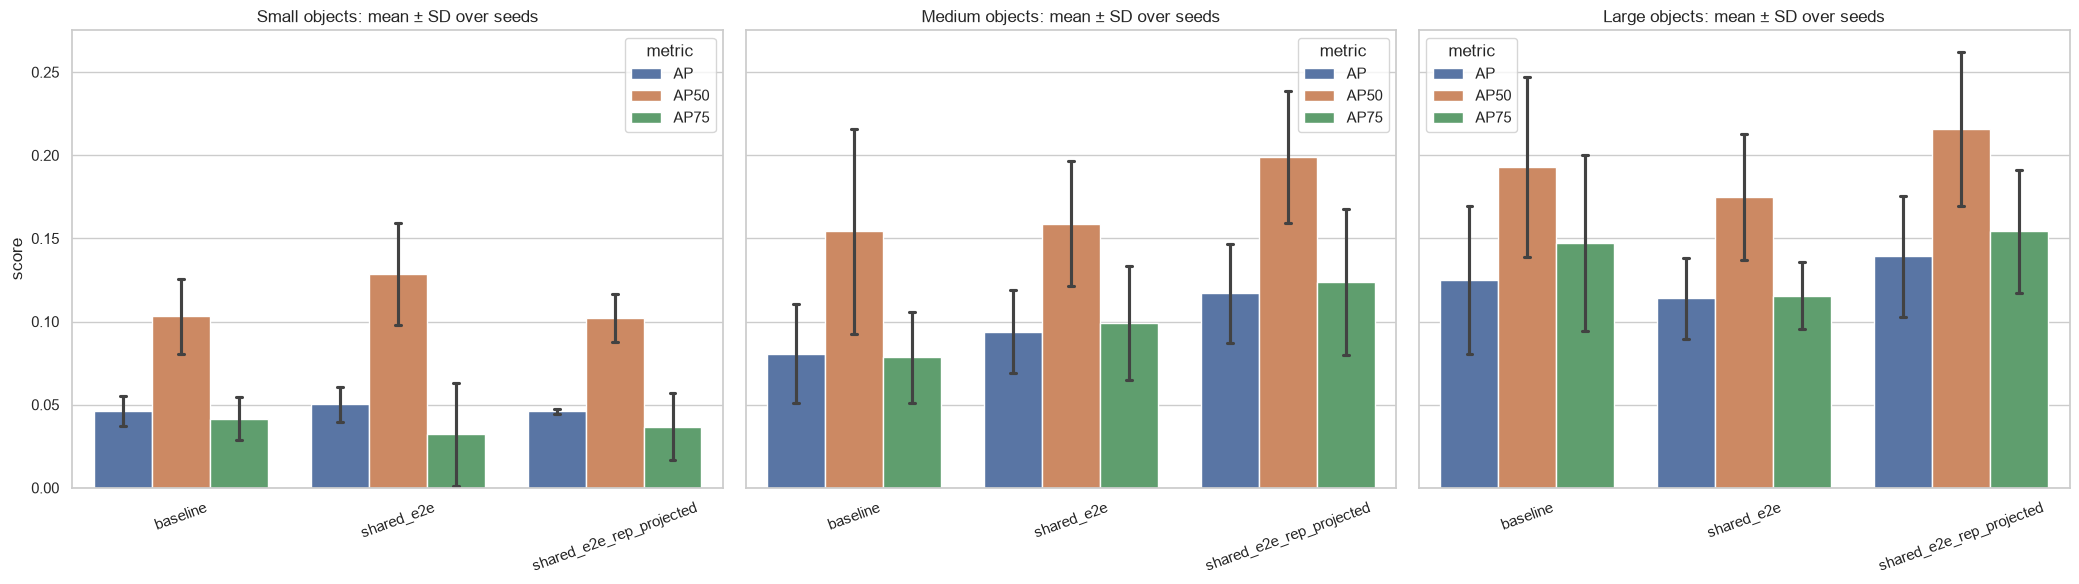

In [25]:
plot_df = scale_df.melt(
    id_vars=['experiment', 'seed', 'scale'], value_vars=['AP', 'AP50', 'AP75'],
    var_name='metric', value_name='value',
)
OBJECT_SCALE_FIGURE_PATH = CONFIG.output_dir / 'shared_e2e_rep_projection_object_scale_ap.png'
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
for axis, scale in zip(axes, ['small', 'medium', 'large']):
    sns.barplot(
        data=plot_df.query('scale == @scale'), x='experiment', y='value', hue='metric',
        order=EXPERIMENTS, estimator='mean', errorbar='sd', capsize=0.08, ax=axis,
    )
    axis.set_title(f'{scale.capitalize()} objects: mean ± SD over seeds')
    axis.set_xlabel('')
    axis.set_ylabel('score' if axis is axes[0] else '')
    axis.tick_params(axis='x', rotation=20)
    axis.legend(title='metric')
plt.tight_layout()
fig.savefig(OBJECT_SCALE_FIGURE_PATH, dpi=180, bbox_inches='tight')
print('Saved:', OBJECT_SCALE_FIGURE_PATH)
plt.show()